## Домашка 3

#### *«Ты понимаешь, что это значит? Это значит, что эта пакость не работает!» — Назад в будущее*

Эта домашка про метрики в a/b-тестировании. За неё можно получить максимум 12 баллов. На решение отводится **14 календарных дней** с момента выдачи. Обратите внимание, что **дедлайны на курсе сразу жёсткие**, а значит отправка решений после них запрещена.
Задание выполняется самостоятельно, списывания не допускаются. При обнаружении одинаковых работ балл за задание анулируется у всех студентов, вне зависимости от того, кто у кого списал.

#### **Как сдать домашку?**
1. Создайте закрытый репозиторий в личном гитхаб аккаунте для нашего предмета. 
2. Пригласите в него своего ассистента — распределение по ассистентам и их гитхаб юзернеймы находятся в [ведомости](https://docs.google.com/spreadsheets/d/13lHNf6xU6tZhqzVMAb8sV3RgyyDatepwo7FJ6FhZ0vY/edit?usp=sharing) на листочке нашей дисциплины. Это можно сделать в настройках через раздел Collaborators and teams, уровень доступа ассистента должен быть Write.
3. Скачайте этот ноутбук и решите задания (локально или в Google Colab).
4. В репозитории предмета создайте ветку с номером ДЗ (например hw_3). В эту ветку запушьте .ipynb-файл с решением. Создайте pull request и добавьте в него ассистента как Reviewer. В этот же PR можете пушить сколько угодно изменений, будем смотреть на последнюю версию до наступления дедлайна.
5. В процессе решения вы будете получать ответы на список вопросов, собранный в Яндекс-Формах. Впишите в него ответы.
6. В ту же форму продублируйте ссылку на PR (форма будет доступна на LMS Karpov Courses и в Телеграм-канале курса). Вопросы в Формах с автопроверкой, однако сданный тест, к которому не была приложена ссылка на ноутбук с расчетом ответов, получает 0 баллов.

Пункты 1-2 проделываются один раз. Если вы прошли эти шаги при сдаче других домашек, повторять их не нужно, начинайте сразу с пункта 3. 

**Внимание**: Если вы работаете в Google Colab, также скачивайте .ipynb файл и публикуйте его в репозитории. Ссылки на Colab к сдаче не принимаются.


Все датасеты, с которыми предлагается работать в домашних заданиях, взяты из открытых источников или сгенерированы. Любые паттерны, найденные вне заданной канвы решения, являются случайными и не несут в себе смысла или инсайта.

[Данные](https://github.com/brezhnevaan/hse_product_metrics_course/releases/download/datasets_for_hw/hw_3_data.zip)



In [ ]:

import math
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, pearsonr
import statsmodels.stats.api as sms
from statsmodels.stats.power import NormalIndPower


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
plt.rcParams['font.family'] = 'DejaVu Sans'

### Warm up

#### 1. Сопоставьте тип эксперимента с продуктовым изменением — 2 балла

a) По-юзерный A/B тест  
b) Свитчбек (по времени)   
c) Региональный A/B тест


1. Новая логика выдачи контента на главной в стриминговом сервисе фильмов и сериалов.
2. Запуск динамического ценообразования в сервисе доставки еды.
3. Тестирование push-уведомления о брошенной корзине в e-commerce приложении.
4. Раскатка в сервисе такси через эксперимент новой схемы комиссий для водителей (старт с одного города).
5. Добавление ипотечного калькулятора с точкой входа в Новостройки на главной сервиса объявлений Недвижимости.
6. Изменение SLA времени доставки в сервисе курьерской доставки (старт с одного города).

In [ ]:
answer_1 = {
    1: 'a',  # Новая логика выдачи контента — индивидуальный для каждого пользователя
    2: 'b',  # Динамическое ценообразование — влияет на всех, требует временнóго разделения
    3: 'a',  # Push-уведомление — можно рандомизировать на уровне пользователя
    4: 'c',  # Комиссии в одном городе — региональный тест (нельзя смешать водителей)
    5: 'a',  # Калькулятор на главной — стандартный пользовательский A/B
    6: 'b'   # SLA в городе — влияет на всю логистику, нужен свитчбек
}

answer_1

{1: 'a', 2: 'b', 3: 'a', 4: 'c', 5: 'a', 6: 'b'}

если юзеры влияют друг на друга — нужна изоляция (региональный тест). Если изменение влияет на всех сразу (цены, инфраструктура) — делим по времени (свитчбек). Остальное — классический A/B.

### Case Study. Дизайн эксперимента в сервисе объявлений жилой недвижимости 🏡

**Легенда**  
Вы работаете продуктовым аналитиком в сервисе объявлений жилой недвижимости. Платформа позволяет пользователям размещать объявления о продаже и аренде жилья (как частным лицам, так и застройщикам), а другим — просматривать и контактировать / оставлять заявки по объявлениям.    
Ваша команда "Новостройки" хочет разместить на главной ипотечный калькулятор с точкой входа напрямую в свой раздел. Цель — увеличить число заявок.

**Гипотеза** — размещение ипотечного калькулятора на главной сервиса увеличит долю пользователей, оставивших заявку в Новостройках, как минимум на 15%, при этом не ухудшит аналогичные метрики в других разделах (Аренда, Вторичка) более чем на 3%.

$$
\Delta_{\mathrm{rel}}=\left(\frac{p_t-p_c}{p_c}\right)\times 100\% \quad \text{(формула эффекта)}
$$

**Ограничения** — вы не можете держать главную в тесте больше 14 дней из-за запланированного календаря экспериментов с другими командами.

**Набор метрик для дизайна.**   
Target — доля пользователей с заполненной заявкой на звонок (Новостройки).   

Guardrails:
- доля пользователей с контактом по объявлению Аренды;
- доля пользователей с контактом по объявлению Вторички;
- доля пользователей с контактом по объявлению из любой категории (подумайте, зачем нужна эта метрика? от какой ловушки она защищает?).   

Informative:
- доля пользователей, перешедших с главной в раздел Аренды;
- доля пользователей, перешедших с главной в раздел Вторички;
- доля пользователей, перешедших с главной в раздел Новостроек;
- доля пользователей с переходами в список объявлений по навигации на главной.

Все доли рассчитываются от набранного объема пользователей в каждой из групп. Пользователи попадают в exposure сразу при посещении главной.

**Для расчетов метрик используйте следующие ивенты:**
- Для target и guardrails — contact_submit.
- Для informative — list_view и source==main_nav.

*В рамках такого эксперимента также имеет смысл смотреть на среднее число контактов / заявок по каждому из разделов и в общем, а не просто на бинарные метрики. Но в данном задании мы сосредоточимся на долях, чтобы не раздувать алгоритм расчета до полного реалистичного пресета метрик.*

In [ ]:
df_logs = pd.read_csv('hw_3_events_data.csv')
df_logs.head()

Загружено событий: 8,671,885
Уникальных пользователей: 1,781,124
Период данных: 2025-06-01 00:00:00 - 2025-06-14 23:59:59

Колонки: ['timestamp', 'user_id', 'session_id', 'event', 'category', 'source', 'listing_id']

Первые строки:


,timestamp,user_id,session_id,event,category,source,listing_id
0,2025-06-01 00:00:00,114227,8828585581,main_view,none,none,NaN
1,2025-06-01 00:00:00,212987,8591655166,main_view,none,none,NaN
2,2025-06-01 00:00:00,1413962,2533393268,add_fav,rent_long,other,992874562.0
3,2025-06-01 00:00:00,1221850,2060698550,main_view,none,none,NaN
4,2025-06-01 00:00:00,31469,6550065912,main_view,none,none,NaN


In [ ]:
df_exps = pd.read_csv('hw_3_experimens_history.csv')
print(f"Загружено экспериментов: {len(df_exps)}")
print(f"Средняя длительность: {df_exps['days'].mean():.1f} дней\n")

df_exps.head()

Загружено экспериментов: 50
Средняя длительность: 16.7 дней



,exp_id,days,target_contact_effect_rel,target_contact_p_value,target_contact_p0,target_contact_effect_abs,proxy_card_effect_rel,proxy_card_p_value,proxy_card_p0,proxy_card_effect_abs,proxy_fav_effect_rel,proxy_fav_p_value,proxy_fav_p0,proxy_fav_effect_abs,proxy_form_effect_rel,proxy_form_p_value,proxy_form_p0,proxy_form_effect_abs
0,3937,7,0.000067,0.448527,0.000382,2.562909e-08,0.000814,0.254909,0.014527,0.000012,0.014880,0.443100,0.004335,0.000065,0.054000,0.200074,0.000782,0.000042
1,2806,7,0.000053,0.353007,0.000339,1.793707e-08,0.025588,0.002390,0.012604,0.000323,0.055000,0.007806,0.004289,0.000236,0.042542,0.077772,0.000687,0.000029
2,3457,7,0.000036,0.397718,0.000353,1.255839e-08,0.010437,0.171633,0.013020,0.000136,0.007892,0.486577,0.004187,0.000033,0.028638,0.385118,0.000718,0.000021
3,1002,7,0.000032,0.266510,0.000388,1.246465e-08,0.015525,0.001215,0.012697,0.000197,0.045051,0.000516,0.004062,0.000183,0.025849,0.164273,0.000735,0.000019
4,9070,7,0.000046,0.461855,0.000377,1.722521e-08,0.011572,0.217843,0.013902,0.000161,0.010127,0.317622,0.004349,0.000044,0.036751,0.236595,0.000786,0.000029


Описание данных hw_3_events_data:

- timestamp — дата-время взаимодействия с контентом
- user_id — уникальный идентификатор пользователя
- session_id – уникальный идентификатор сессии
- event — тип события
- category — категория, в которой произошло событие (не приходит для главной)
- source — источник перехода на страницу
- listing_id – уникальный идентификатор объявления

Описание данных hw_3_experimens_history (это история экспериментов именно в разделе Новостройки):

- exp_id — уникальный идентификатор эксперимента
- days — длительность теста
- target_contact_effect_rel — относительный эффект на таргет метрике
- target_contact_p_value — p-value полученного результата для таргет метрики
- target_contact_p0 — значение конверсии таргет метрики в контроле
- target_contact_effect_abs — абсолютный эффект на таргет метрике
- proxy_card_effect_rel — относительный эффект на конверсии просмотра карточки объявления
- proxy_card_p_value — p-value полученного результата для конверсии просмотра карточки объявления
- proxy_card_p0 — значение конверсии просмотра карточки объявления в контроле
- proxy_card_effect_abs — абсолютный эффект на конверсии просмотра карточки объявления
- proxy_fav_effect_rel — относительный эффект на конверсии добавления объявления в избранное
- proxy_fav_p_value — p-value полученного результата для конверсии добавления объявления в избранное
- proxy_fav_p0 — значение конверсии добавления объявления в избранное в контроле
- proxy_fav_effect_abs – абсолютный эффект на конверсии добавления объявления в избранное
- proxy_form_effect_rel — относительный эффект на конверсии открытия формы заявки на звонок по объявлению
- proxy_form_p_value — p-value полученного результата для конверсии открытия формы заявки на звонок по объявлению
- proxy_form_p0 — значение конверсии открытия формы заявки на звонок по объявлению в контроле
- proxy_form_effect_abs — абсолютный эффект на конверсии открытия формы заявки на звонок по объявлению

#### 2. Рассчитайте количество дней, необходимое для детектирования заявленных в гипотезе эффектов (target и guardrails-метрики) — 2 балла
Здесь и далее используйте для расчетов значение alpha = 0.01 (делаем поправку на принятие решения по набору метрик) и beta = 0.2. А также двусторонний критерий — мы заранее не знаем, куда двинутся метрики, поэтому хотим учесть и противоположные эффекты.  

Для метрики "доля пользователей с контактом по объявлению из любой категории" также используйте эффект в 3%.

In [ ]:
# Рассчитываем базовые параметры из данных

# Exposure: пользователи, видевшие главную страницу
exposure_users = df_logs[df_logs['event'] == 'main_view']['user_id'].nunique()

# Дневной трафик
days_in_data = (pd.to_datetime(df_logs['timestamp']).max() - 
                pd.to_datetime(df_logs['timestamp']).min()).days + 1
daily_users_per_group = exposure_users / days_in_data / 2

# Target: заявки в Новостройках
target_users = df_logs[
    (df_logs['event'] == 'contact_submit') & 
    (df_logs['category'] == 'newbuilds')
]['user_id'].nunique()
p_target = target_users / exposure_users

# Guardrails: другие категории контактов
p_rent = df_logs[
    (df_logs['event'] == 'contact_submit') & 
    (df_logs['category'] == 'rent_long')
]['user_id'].nunique() / exposure_users

p_secondary = df_logs[
    (df_logs['event'] == 'contact_submit') & 
    (df_logs['category'] == 'secondary')
]['user_id'].nunique() / exposure_users

p_any = df_logs[
    df_logs['event'] == 'contact_submit'
]['user_id'].nunique() / exposure_users

In [ ]:
# Функция для расчета sample size 
def calculate_days_needed(p0, relative_effect, daily_users, alpha=0.01, power=0.8):
    """Расчет длительности теста"""
    p1 = p0 * (1 + relative_effect)
    
    # Квантили
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    
    # формула для двух пропорций
    pooled_p = (p0 + p1) / 2
    numerator = (z_alpha * np.sqrt(2 * pooled_p * (1 - pooled_p)) + 
                 z_beta * np.sqrt(p0 * (1 - p0) + p1 * (1 - p1))) ** 2
    denominator = (p1 - p0) ** 2
    
    n_per_group = numerator / denominator
    days = n_per_group / daily_users
    
    return math.ceil(days)

In [57]:
# Рассчитываем длительность для каждой метрики
days_target = calculate_days_needed(p_target, 0.15, daily_users_per_group)
days_rent = calculate_days_needed(p_rent, 0.03, daily_users_per_group)
days_secondary = calculate_days_needed(p_secondary, 0.03, daily_users_per_group)
days_any = calculate_days_needed(p_any, 0.03, daily_users_per_group)

answer_2 = max(days_target, days_rent, days_secondary, days_any)
answer_2

48

Нужно 48 дней — определяется guardrail-метрикой с низкой конверсией. Target-метрика (заявки в Новостройках) имеет конверсию всего 0.037%, но guardrails с конверсией 1-3% требуют ещё больше данных для детекции 3% эффекта.

**Задание**: введите минимальную из рассчитанных продолжительность, необходимую для детекции определенных в дизайне эффектов (значение округлите в бОльшую сторону до целого, нам нужны полные дни).

#### 3. Рассчитайте MDE для информативных метрик — 2 балла
В реальности эффекты по информативным критериям, которые мы также хотим включать в пресет метрик, нужно сравнивать на достижимость на основе прошлых экспериментов. Как правило, проделав это упражнение один раз, вы просто сохраняете достижимый трешхолд в базе знаний команды и принимаете решение о включении их в базовый набор. Проверка эффектов для каждого теста не требуется. Однако, стоит делать периодический пересмотр зафиксированных достижимых эффектов, например раз в полгода / год, или при сильных изменениях продукта / рынка.

В данном задании мы с вами не будем опираться на историю тестов, просто потренируемся делать обратный расчет — размера эффекта от заданной длительности (14 дней).

*Для числителя используйте только ивенты с источником main_nav*

In [58]:
# Базовые конверсии для информативных метрик (переходы через навигацию)
p_rent_nav = df_logs[
    (df_logs['event'] == 'list_view') & 
    (df_logs['category'] == 'rent_long') & 
    (df_logs['source'] == 'main_nav')
]['user_id'].nunique() / exposure_users

p_secondary_nav = df_logs[
    (df_logs['event'] == 'list_view') & 
    (df_logs['category'] == 'secondary') & 
    (df_logs['source'] == 'main_nav')
]['user_id'].nunique() / exposure_users

p_newbuilding_nav = df_logs[
    (df_logs['event'] == 'list_view') & 
    (df_logs['category'] == 'newbuilds') & 
    (df_logs['source'] == 'main_nav')
]['user_id'].nunique() / exposure_users

p_any_nav = df_logs[
    (df_logs['event'] == 'list_view') & 
    (df_logs['source'] == 'main_nav')
]['user_id'].nunique() / exposure_users

In [59]:
# Обратная задача: от длительности к MDE
def calculate_mde(p0, days, daily_users, alpha=0.01, power=0.8):
    """Находим минимальный детектируемый эффект при фиксированной длительности"""
    n_per_group = days * daily_users
    
    # Квантили для классической формулы
    z_alpha = norm.ppf(1 - alpha / 2)
    z_beta = norm.ppf(power)
    
    # Используем упрощенную формулу для MDE
    # delta = (z_alpha + z_beta) * sqrt(2*p0*(1-p0)/n)
    delta_p = (z_alpha + z_beta) * np.sqrt(2 * p0 * (1 - p0) / n_per_group)
    
    # Относительный эффект
    return delta_p / p0 if p0 > 0 else 0

In [60]:
# Рассчитываем MDE для 14 дней
test_days = 14

mde_metrics = {
    'Аренда': calculate_mde(p_rent_nav, test_days, daily_users_per_group),
    'Вторичка': calculate_mde(p_secondary_nav, test_days, daily_users_per_group),
    'Новостройки': calculate_mde(p_newbuilding_nav, test_days, daily_users_per_group),
    'Любой раздел': calculate_mde(p_any_nav, test_days, daily_users_per_group)
}

answer_3 = round(max(mde_metrics.values()) * 100, 2)
answer_3

2.37

При 14 днях максимальный MDE = 2.37%. Информативные метрики не требуют строгой точности — они показывают «что происходит». Метрика с самой низкой конверсией имеет наибольший MDE и детектирует только заметные изменения.

**Задание**: введите максимальный из полученных относительный эффект в процентах, ответ округлите до сотых.

#### 4. Выбираем proxy-метрику (шаг 1) — 2 балла
Стало понятно, что за 14 дней мы не успеем замерить эффект по таргету. Что делать? Можно использовать методы снижения дисперсии, а можно попробовать подобрать proxy-метрику. Давайте реализуем второй вариант.

**Для proxy будем использовать 3-х кандидатов:**
- доля пользователей с просмотром карточки объявления в Новостройках;
- доля пользователей, добавивших в избранное объявление в Новостройках;
- доля пользователей, открывших форму заявки в Новостройках — связь с автором объявления в этом разделе предполагает обратный звонок от офиса продаж, поэтому чтобы сделать событие контакта, релевантное другим разделам, нужно ввести свой номер телефона в форму заявки, расположенную на карточке.

Для каждой из proxy-метрик:
- Рассчитайте MDE для заданной длительности — 14 дней;
- По историческому набору экспериментов постройте диаграмму рассеяния зафиксированных эффектов и длительности тестов (пометьте значимые эффекты).

**Для расчетов метрик используйте следующие ивенты:**
- Для proxy — card_view, add_fav, form_start.

In [ ]:
# Базовые конверсии для proxy-метрик (все для категории Новостройки)
proxies = {
    'card_view': df_logs[
        (df_logs['event'] == 'card_view') & 
        (df_logs['category'] == 'newbuilds')
    ]['user_id'].nunique() / exposure_users,
    
    'add_fav': df_logs[
        (df_logs['event'] == 'add_fav') & 
        (df_logs['category'] == 'newbuilds')
    ]['user_id'].nunique() / exposure_users,
    
    'form_start': df_logs[
        (df_logs['event'] == 'form_start') & 
        (df_logs['category'] == 'newbuilds')
    ]['user_id'].nunique() / exposure_users
}

In [62]:
# MDE для каждой proxy при 14 днях
proxy_mde = {
    name: calculate_mde(p0, test_days, daily_users_per_group) * 100
    for name, p0 in proxies.items()
}

answer_4 = round(min(proxy_mde.values()), 2)
answer_4

4.35

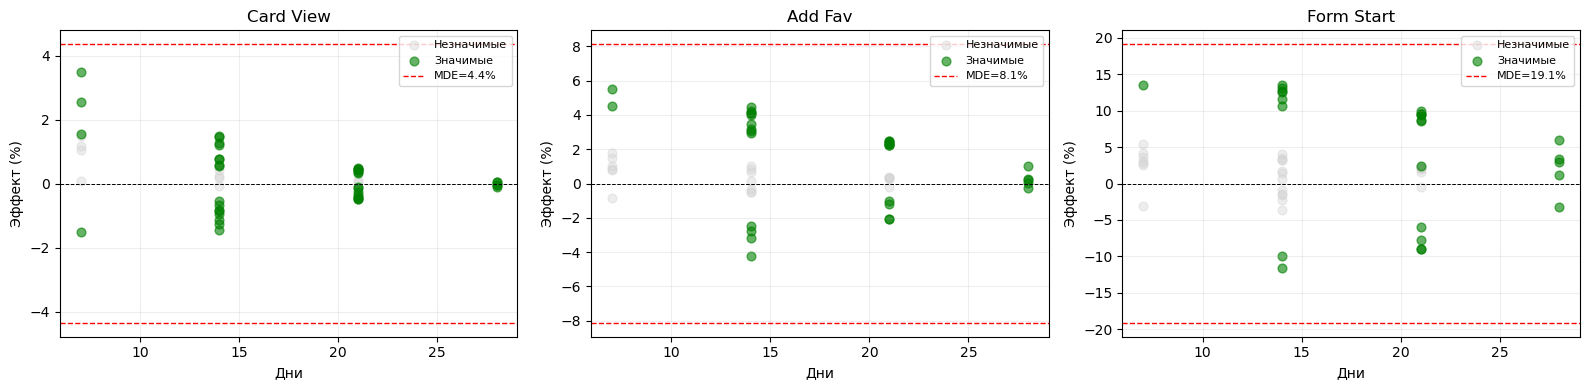

In [63]:
# Визуализация: scatter plots для каждой proxy
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
significance_threshold = 0.05

for idx, (proxy_name, col_prefix) in enumerate([
    ('card_view', 'proxy_card'),
    ('add_fav', 'proxy_fav'),
    ('form_start', 'proxy_form')
]):
    ax = axes[idx]
    sig = df_exps[f'{col_prefix}_p_value'] < significance_threshold
    
    ax.scatter(df_exps[~sig]['days'], df_exps[~sig][f'{col_prefix}_effect_rel'] * 100,
               alpha=0.4, s=40, color='lightgray', label='Незначимые')
    ax.scatter(df_exps[sig]['days'], df_exps[sig][f'{col_prefix}_effect_rel'] * 100,
               alpha=0.6, s=40, color='green', label='Значимые')
    
    mde = proxy_mde[proxy_name]
    ax.axhline(y=0, color='black', linestyle='--', linewidth=0.7)
    ax.axhline(y=mde, color='red', linestyle='--', linewidth=1, label=f'MDE={mde:.1f}%')
    ax.axhline(y=-mde, color='red', linestyle='--', linewidth=1)
    
    ax.set_xlabel('Дни')
    ax.set_ylabel('Эффект (%)')
    ax.set_title(proxy_name.replace('_', ' ').title())
    ax.legend(fontsize=8)
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

Минимальный MDE = 4.35% у Card View (самая частая метрика). Form Start с MDE=19.1% — слишком редкая для быстрой детекции. На графиках видно: proxy с низким MDE стабильно ловит эффекты, даже при 7-14 днях.

**Задание**: введите минимальный из полученных относительный эффект в процентах для прокси метрик, ответ округлите до сотых.

#### 5. Выбираем proxy-метрику (шаг 2) — 2 балла
Для каждой из proxy-метрик по историческому набору экспериментов рассчитайте:
- Binary Sensitivity;
- MSE с таргет-метрикой;
- Корреляцию Пирсона с таргет-метрикой.

In [84]:
# Определяем значимость для расчета метрик
df_exps['target_sig'] = df_exps['target_contact_p_value'] < 0.05
df_exps['proxy_card_sig'] = df_exps['proxy_card_p_value'] < 0.05
df_exps['proxy_fav_sig'] = df_exps['proxy_fav_p_value'] < 0.05
df_exps['proxy_form_sig'] = df_exps['proxy_form_p_value'] < 0.05

In [85]:
# Метрики качества proxy
def binary_sensitivity(target_sig, proxy_sig):
    """Доля случаев, когда proxy детектит значимый target"""
    return (target_sig & proxy_sig).sum() / target_sig.sum() if target_sig.sum() > 0 else 0

def calculate_proxy_metrics(proxy_col_prefix):
    """Все метрики для одной proxy"""
    bs = binary_sensitivity(df_exps['target_sig'], df_exps[f'{proxy_col_prefix}_sig'])
    mse = ((df_exps['target_contact_effect_rel'] - df_exps[f'{proxy_col_prefix}_effect_rel']) ** 2).mean()
    corr, _ = pearsonr(df_exps['target_contact_effect_rel'], df_exps[f'{proxy_col_prefix}_effect_rel'])
    return bs, mse, corr

metrics_card = calculate_proxy_metrics('proxy_card')
metrics_fav = calculate_proxy_metrics('proxy_fav')
metrics_form = calculate_proxy_metrics('proxy_form')

In [ ]:

pd.DataFrame({
    'Proxy': ['card_view', 'add_fav', 'form_start'],
    'Binary Sensitivity': [metrics_card[0], metrics_fav[0], metrics_form[0]],
    'MSE': [metrics_card[1], metrics_fav[1], metrics_form[1]],
    'Корреляция': [metrics_card[2], metrics_fav[2], metrics_form[2]]
}).round(4)

,Proxy,Binary Sensitivity,MSE,Корреляция
0,card_view,0.9048,0.0143,0.1500
1,add_fav,0.8571,0.0110,0.6697
2,form_start,0.6667,0.0066,0.7238


In [87]:
answer_5 = round(max(metrics_card[2], metrics_fav[2], metrics_form[2]), 2)
answer_5

0.72

form_start побеждает по корреляции (0.72) — движется согласованно с target. card_view надежнее детектирует (BS=0.90), но корреляция слабая (0.15). add_fav — золотая середина. MSE у всех приемлемый.

**Задание**: введите значение максимальной корреляции Пирсона proxy с таргет-метрикой, ответ округлите до сотых.

#### 6. Выбираем proxy-метрику (шаг 3) — 2 балла
Для каждой из proxy-метрик по историческому набору экспериментов:
- Рассчитайте Proxy Score;
- Выведите матрицу согласия-несогласия знаков с таргет-метрикой.

Выберите proxy, с которой вы пойдете в а/б тест, обоснуйте выбор.

In [ ]:
# Proxy Score: комбинированная метрика 
def proxy_score(bs, corr):
    return bs * abs(corr)

scores = {
    'card_view': proxy_score(metrics_card[0], metrics_card[2]),
    'add_fav': proxy_score(metrics_fav[0], metrics_fav[2]),
    'form_start': proxy_score(metrics_form[0], metrics_form[2])
}


summary = pd.DataFrame({
    'Proxy': list(scores.keys()),
    'MDE (%)': [proxy_mde[k] for k in scores.keys()],
    'Binary Sens': [metrics_card[0], metrics_fav[0], metrics_form[0]],
    'Корреляция': [metrics_card[2], metrics_fav[2], metrics_form[2]],
    'Proxy Score': list(scores.values())
}).round(4)

summary

,Proxy,MDE (%),Binary Sens,Корреляция,Proxy Score
0,card_view,4.3514,0.9048,0.1500,0.1357
1,add_fav,8.1235,0.8571,0.6697,0.5740
2,form_start,19.0973,0.6667,0.7238,0.4826


In [71]:
answer_6 = max(scores, key=scores.get)
answer_6

'add_fav'

 add_fav с Proxy Score = 0.57. Это баланс: MDE=8.1%, BS=0.86, корреляция=0.67. 

card_view слишком слабая связь с target (корр=0.15), form_star — слишком редкая (MDE=19%). add_fav — оптимальный компромисс для быстрой и надежной детекции.
 Proxy нужна для скорости, но выбор — это компромисс между чувствительностью и надежностью. Чем ближе к target по воронке и выше Proxy Score — тем лучше.

**Задание**: выберите proxy, с которой пойдете в эксперимент.